1/3: Cargando datos (ALADIN y CR2MET)...
2/3: Computando cálculos a memoria (Esto tomará unos segundos)...
3/3: Graficando comparación lado a lado...


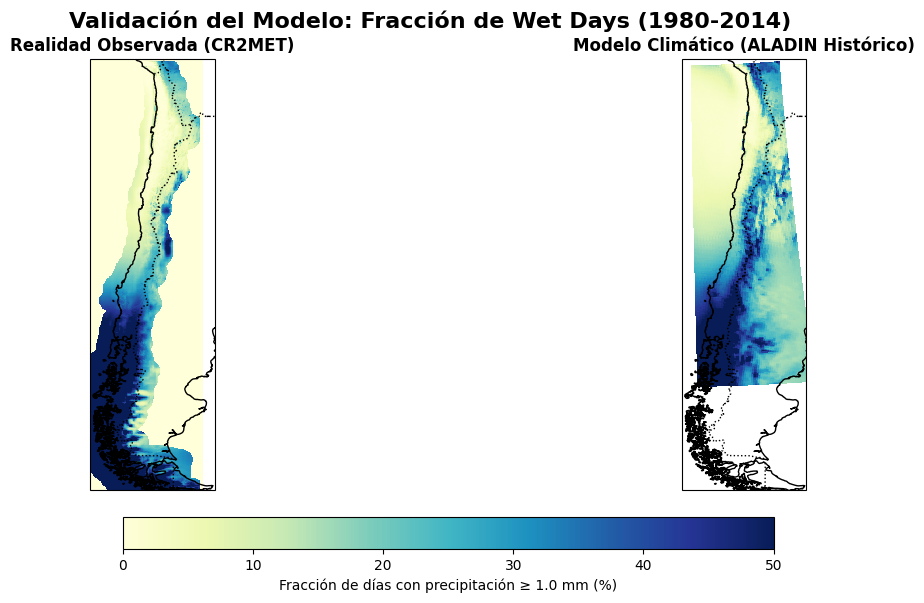

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings

warnings.filterwarnings('ignore')

print("1/3: Cargando datos (ALADIN y CR2MET)...")

# 1. ALADIN (El modelo con el Drizzle Bias)
ds_aladin = xr.open_mfdataset('./pr1/pr_CHP12_*_historical_*.nc', use_cftime=True, chunks={'time': 365})
pr_aladin = ds_aladin['pr'].sel(time=slice('1980-01-01', '2014-12-31')) * 86400
wet_aladin = (pr_aladin >= 1.0).mean(dim='time') * 100

# 2. CR2MET (La realidad observada)
# Ajusta el nombre de la carpeta si es diferente a './pr/'
ds_cr2met = xr.open_mfdataset('./pr/CR2MET_pr_v2.5_day_*.nc', chunks={'time': 365})
pr_cr2met = ds_cr2met['pr'].sel(time=slice('1980-01-01', '2014-12-31'))
wet_cr2met = (pr_cr2met >= 1.0).mean(dim='time') * 100

print("2/3: Computando cálculos a memoria (Esto tomará unos segundos)...")
wet_aladin_c = wet_aladin.compute()
wet_cr2met_c = wet_cr2met.compute()

print("3/3: Graficando comparación lado a lado...")
fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# --- Mapa 1: CR2MET (Realidad) ---
ax1 = axes[0]
ax1.add_feature(cfeature.COASTLINE)
ax1.add_feature(cfeature.BORDERS, linestyle=':')
ax1.set_extent([-76, -65, -55, -17])
im1 = wet_cr2met_c.plot.pcolormesh(ax=ax1, x='lon', y='lat', transform=ccrs.PlateCarree(), 
                                   cmap='YlGnBu', vmin=0, vmax=50, add_colorbar=False)
ax1.set_title("Realidad Observada (CR2MET)", fontweight='bold')

# --- Mapa 2: ALADIN (Modelo) ---
ax2 = axes[1]
ax2.add_feature(cfeature.COASTLINE)
ax2.add_feature(cfeature.BORDERS, linestyle=':')
ax2.set_extent([-76, -65, -55, -17])
# ALADIN es una grilla proyectada, no olvides indicarle explícitamente x='lon', y='lat'
im2 = wet_aladin_c.plot.pcolormesh(ax=ax2, x='lon', y='lat', transform=ccrs.PlateCarree(), 
                                   cmap='YlGnBu', vmin=0, vmax=50, add_colorbar=False)
ax2.set_title("Modelo Climático (ALADIN Histórico)", fontweight='bold')

# Barra de color unificada
cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), orientation='horizontal', shrink=0.6, pad=0.05)
cbar.set_label('Fracción de días con precipitación ≥ 1.0 mm (%)')

plt.suptitle("Validación del Modelo: Fracción de Wet Days (1980-2014)", fontsize=16, fontweight='bold', y=0.95)
plt.show()